### Cell 0 - Imports


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline



StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 23, Finished, Available, Finished, False)

### Cell 1


In [7]:

df = pd.read_csv("/lakehouse/default/Files/ml/vw_user_features_v1.csv")
df.shape, df.head()

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 9, Finished, Available, Finished, False)

((393, 13),
                                 user_id  total_events  days_active  \
 0  41d4ee27-0b5e-4d95-a0df-05c2b4ed22fb         90387            1   
 1  91dc832f-4b64-48fe-8ecd-6c3d78ed7497           223            5   
 2  b340972b-8871-48db-ae55-69d3644a0c84           202           10   
 3  8a0803e8-68df-48f1-b226-1c011bbf7d28           168            4   
 4  d6b904a1-8ae3-42fd-952c-b53a357375b6           165           29   
 
    total_meetings  total_interactions  total_tech_questions  \
 0           90374                  13                     0   
 1              80                  45                    98   
 2              50                  26                   126   
 3              80                  38                    30   
 4              40                  64                    61   
 
    total_risk_assessments  pct_unknown_category  technicalAbility_avg  \
 0                       0                0.5572              2.380308   
 1                       0

In [15]:
df.info()
df.describe().T

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 17, Finished, Available, Finished, False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   393 non-null    object 
 1   total_events              393 non-null    int64  
 2   days_active               393 non-null    int64  
 3   total_meetings            393 non-null    int64  
 4   total_interactions        393 non-null    int64  
 5   total_tech_questions      393 non-null    int64  
 6   total_risk_assessments    393 non-null    int64  
 7   pct_unknown_category      393 non-null    float64
 8   technicalAbility_avg      103 non-null    float64
 9   attitude_avg              77 non-null     float64
 10  argumentation_avg         77 non-null     float64
 11  articulation_avg          77 non-null     float64
 12  negotiation_avg           77 non-null     float64
 13  total_events_cap_p99      393 non-null    float64
 14  log_total_

,count,mean,std,min,25%,50%,75%,max
total_events,393.0,259.038168,4558.061437,1.000000,5.000000,23.000000,41.00000,90387.000000
days_active,393.0,1.674300,1.773034,1.000000,1.000000,1.000000,2.00000,29.000000
total_meetings,393.0,241.641221,4558.218735,0.000000,0.000000,0.000000,30.00000,90374.000000
total_interactions,393.0,6.338422,7.810575,0.000000,2.000000,5.000000,8.00000,80.000000
total_tech_questions,393.0,10.493639,17.293847,0.000000,0.000000,0.000000,22.00000,126.000000
total_risk_assessments,393.0,0.564885,2.951390,0.000000,0.000000,0.000000,0.00000,30.000000
pct_unknown_category,393.0,0.998873,0.022336,0.557200,1.000000,1.000000,1.00000,1.000000
technicalAbility_avg,103.0,2.039407,0.314717,1.666667,1.750000,2.000000,2.25000,3.000000
attitude_avg,77.0,1.970923,0.414312,1.000000,1.750000,2.000000,2.25000,3.000000
argumentation_avg,77.0,2.021858,0.403400,1.000000,1.750000,2.000000,2.25000,3.000000


### Cell 3 - Carregar + tipos + corrigir zeros

In [8]:

# garantir numéricos
count_cols = ["total_events","days_active","total_meetings","total_interactions","total_tech_questions","total_risk_assessments"]
for c in count_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

float_cols = ["pct_unknown_category","technicalAbility_avg","attitude_avg","argumentation_avg","articulation_avg","negotiation_avg"]
for c in float_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# tratar zeros como missing nas dimensões socioargumentativas
zero_as_missing = ["attitude_avg","argumentation_avg","articulation_avg","negotiation_avg"]
for c in zero_as_missing:
    df.loc[df[c] == 0, c] = np.nan

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 10, Finished, Available, Finished, False)

### Cell 4 - Outlier handling (cap p99 + log)

In [11]:
s = df["total_events"].astype(float)
p99 = np.nanpercentile(s, 99)

df["total_events_cap_p99"] = np.minimum(df["total_events"], p99)
df["log_total_events_cap_p99"] = np.log1p(df["total_events_cap_p99"])

df["events_per_day"] = df["total_events"] / df["days_active"].replace(0, np.nan)
df["events_per_day"] = df["events_per_day"].fillna(0)

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 13, Finished, Available, Finished, False)

### Cell 5 - Definir quem tem “desempenho válido”

In [13]:
perf_cols = ["technicalAbility_avg","attitude_avg","argumentation_avg","articulation_avg","negotiation_avg"]

df["perf_non_null_count"] = df[perf_cols].notna().sum(axis=1)

# critério: technicalAbility presente + pelo menos 2 das 4 socioargumentativas
df["has_perf_valid"] = df["technicalAbility_avg"].notna() & (df[zero_as_missing].notna().sum(axis=1) >= 2)

df["has_perf_valid"].value_counts()

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 15, Finished, Available, Finished, False)

has_perf_valid
False    315
True      78
Name: count, dtype: int64

### Cell 6 - Gerar os 3 datasets (A/B/C)

In [14]:
features_participation = [
    "log_total_events_cap_p99",
    "days_active",
    "events_per_day",
    "total_meetings",
    "total_interactions",
    "total_tech_questions",
    "total_risk_assessments",
    "pct_unknown_category",
]

features_performance = perf_cols  # já com NaNs tratados

df_A = df.copy()  # 393 usuários
df_B = df[df["has_perf_valid"]].copy()
df_C = df[df["has_perf_valid"]].copy()

df_A.shape, df_B.shape, df_C.shape

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 16, Finished, Available, Finished, False)

((393, 18), (78, 18), (78, 18))

In [18]:
perf_cols = ["technicalAbility_avg","attitude_avg","argumentation_avg","articulation_avg","negotiation_avg"]
df_B[perf_cols].isna().sum()

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 20, Finished, Available, Finished, False)

technicalAbility_avg    0
attitude_avg            1
argumentation_avg       1
articulation_avg        1
negotiation_avg         1
dtype: int64

## 6.2 -> PCA (B) + KMeans (A/C) com validação

### Cell 7 - PCA no desempenho (B)

In [20]:


perf_cols = ["technicalAbility_avg","attitude_avg","argumentation_avg","articulation_avg","negotiation_avg"]

X_perf = df_B[perf_cols].copy()

imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_perf)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_, pca.explained_variance_ratio_.sum()

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 22, Finished, Available, Finished, False)

(array([0.80769218, 0.11777204]), 0.9254642161177391)

### Cell 8 - KMeans + silhouette (A e C)

In [22]:


def kmeans_silhouette_pipeline(df_in, feature_cols, k_min=2, k_max=6, seed=42):
    X = df_in[feature_cols].copy()

    prep = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    Xp = prep.fit_transform(X)

    scores, inertias, models = [], [], {}
    for k in range(k_min, k_max+1):
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(Xp)
        scores.append((k, float(silhouette_score(Xp, labels))))
        inertias.append((k, float(km.inertia_)))
        models[k] = (prep, km)

    return scores, inertias, models

perf_cols = ["technicalAbility_avg","attitude_avg","argumentation_avg","articulation_avg","negotiation_avg"]

features_A = [
    "log_total_events_cap_p99","days_active","events_per_day",
    "total_meetings","total_interactions","total_tech_questions",
    "total_risk_assessments","pct_unknown_category",
]

features_C = features_A + perf_cols

scores_A, inertias_A, models_A = kmeans_silhouette_pipeline(df_A, features_A, 2, 6)
scores_C, inertias_C, models_C = kmeans_silhouette_pipeline(df_C, features_C, 2, 6)

scores_A, scores_C

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 24, Finished, Available, Finished, False)

([(2, 0.9277311852431342),
  (3, 0.31397150836362536),
  (4, 0.33214093813590995),
  (5, 0.37329538570883614),
  (6, 0.40714015272847687)],
 [(2, 0.7570366699908276),
  (3, 0.36307630048712086),
  (4, 0.4022188677616346),
  (5, 0.41089059782736076),
  (6, 0.420176601573916)])

In [23]:
# A: verificar tamanho dos clusters com k=2
prep_A, kmA2 = models_A[2]
XA = prep_A.transform(df_A[features_A])
labelsA2 = kmA2.predict(XA)

df_A.assign(clusterA2=labelsA2)["clusterA2"].value_counts()

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 25, Finished, Available, Finished, False)

clusterA2
0    392
1      1
Name: count, dtype: int64

In [24]:
df_A_no = df_A[df_A["total_events"] < df_A["total_events"].max()].copy()
df_C_no = df_C[df_C["total_events"] < df_C["total_events"].max()].copy()

scores_A_no, inertias_A_no, models_A_no = kmeans_silhouette_pipeline(df_A_no, features_A, 2, 6)
scores_C_no, inertias_C_no, models_C_no = kmeans_silhouette_pipeline(df_C_no, features_C, 2, 6)

scores_A_no, scores_C_no

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 26, Finished, Available, Finished, False)

([(2, 0.3611139481491124),
  (3, 0.36975969678526305),
  (4, 0.43649319010121296),
  (5, 0.45355949400867385),
  (6, 0.4712598389153062)],
 [(2, 0.30508054596909445),
  (3, 0.33698357387610495),
  (4, 0.354074413891458),
  (5, 0.3672587031443539),
  (6, 0.2837771588001954)])

In [25]:
best_k_A_no = 6
best_k_C_no = 5

# A_no
prep_A_no, kmA_no = models_A_no[best_k_A_no]
XA_no = prep_A_no.transform(df_A_no[features_A])
df_A_no["cluster_A"] = kmA_no.predict(XA_no)

centroids_A_no = pd.DataFrame(
    prep_A_no.named_steps["scaler"].inverse_transform(kmA_no.cluster_centers_),
    columns=features_A
)

# C_no
prep_C_no, kmC_no = models_C_no[best_k_C_no]
XC_no = prep_C_no.transform(df_C_no[features_C])
df_C_no["cluster_C"] = kmC_no.predict(XC_no)

centroids_C_no = pd.DataFrame(
    prep_C_no.named_steps["scaler"].inverse_transform(kmC_no.cluster_centers_),
    columns=features_C
)

print("A_no cluster sizes:")
print(df_A_no["cluster_A"].value_counts().sort_index())

print("\nC_no cluster sizes:")
print(df_C_no["cluster_C"].value_counts().sort_index())

centroids_C_no

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 27, Finished, Available, Finished, False)

A_no cluster sizes:
cluster_A
0     16
1    100
2     83
3     11
4    180
5      2
Name: count, dtype: int64

C_no cluster sizes:
cluster_C
0    43
1     7
2    21
3     5
4     1
Name: count, dtype: int64


,log_total_events_cap_p99,days_active,events_per_day,total_meetings,total_interactions,total_tech_questions,total_risk_assessments,pct_unknown_category,technicalAbility_avg,attitude_avg,argumentation_avg,articulation_avg,negotiation_avg
0,3.813111,1.883721,29.773256,38.093023,5.790698,2.558140,4.440892e-16,1.0,1.839147,1.800388,1.860465,1.852713,1.823643
1,4.894135,3.428571,45.247619,71.428571,15.857143,53.285714,1.428571e+00,1.0,2.326531,2.387755,2.367347,2.326531,2.326531
2,3.805602,1.380952,36.269841,36.047619,5.142857,3.952381,0.000000e+00,1.0,2.404762,2.369048,2.444444,2.444444,2.412698
3,4.819174,3.400000,38.766667,71.000000,18.600000,30.000000,7.000000e+00,1.0,2.378571,1.167857,1.167857,1.167857,1.167857
4,5.111988,29.000000,5.689655,40.000000,64.000000,61.000000,0.000000e+00,1.0,1.750000,1.750000,1.750000,1.750000,1.750000


### Validar o singleton e o cluster de 2 (A_no)

In [26]:
# singleton no C_no
df_C_no[df_C_no["cluster_C"] == 4][["user_id","total_events","days_active","events_per_day"] + perf_cols]

# cluster pequeno em A_no
df_A_no[df_A_no["cluster_A"] == 5][["user_id","total_events","days_active","events_per_day"]]

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 28, Finished, Available, Finished, False)

,user_id,total_events,days_active,events_per_day
4,d6b904a1-8ae3-42fd-952c-b53a357375b6,165,29,5.689655
17,4b8e8ff7-7b63-496f-adcd-dfc1dd0da46f,90,12,7.500000


### Rodar dendrograma do C_no

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 29, Finished, Available, Finished, False)

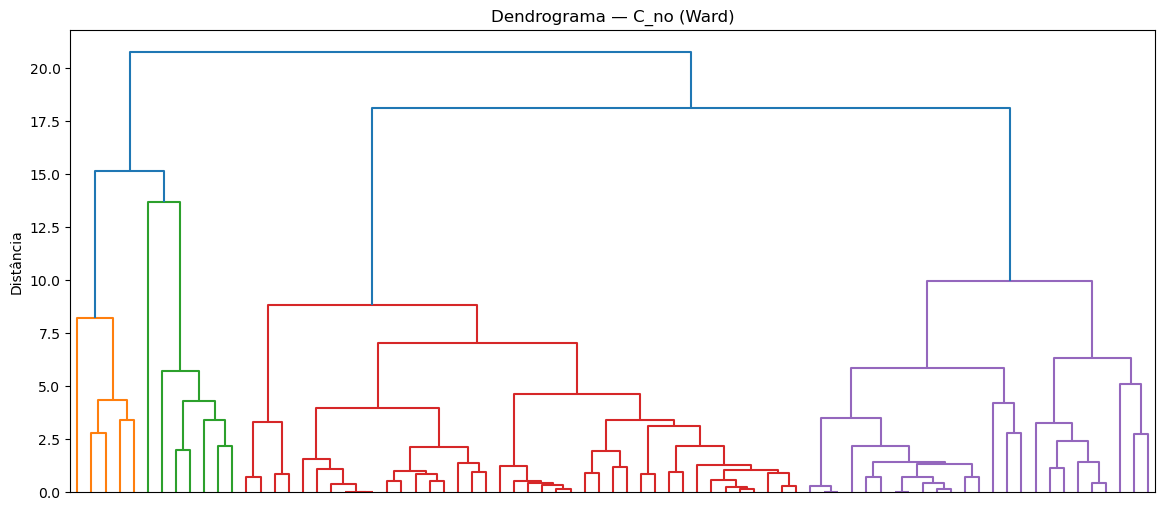

In [27]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

X = prep_C_no.transform(df_C_no[features_C])  # já escalado/imputado
Z = linkage(X, method="ward")

plt.figure(figsize=(14,6))
dendrogram(Z, no_labels=True)
plt.title("Dendrograma — C_no (Ward)")
plt.ylabel("Distância")
plt.show()

clusters_h4 = fcluster(Z, t=4, criterion="maxclust")
clusters_h5 = fcluster(Z, t=5, criterion="maxclust")

In [28]:
profile_map = {
    0: "Participante regular / Desempenho em desenvolvimento",
    1: "Engajado intensivo / Alto desempenho",
    2: "Alto desempenho / Participação enxuta",
    3: "Alta participação / Baixa competência socioargumentativa",
    4: "Caso atípico — engajamento longitudinal",
}
df_C_no["perfil"] = df_C_no["cluster_C"].map(profile_map)
df_C_no["perfil"].value_counts()

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 30, Finished, Available, Finished, False)

perfil
Participante regular / Desempenho em desenvolvimento        43
Alto desempenho / Participação enxuta                       21
Engajado intensivo / Alto desempenho                         7
Alta participação / Baixa competência socioargumentativa     5
Caso atípico — engajamento longitudinal                      1
Name: count, dtype: int64

### Gerar k=4 (só para perfis pedagógicos)

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

k = 4
prep_C_no, _ = models_C_no[5]  # reaproveita o mesmo preprocess
XC_no = prep_C_no.transform(df_C_no[features_C])

km4 = KMeans(n_clusters=k, random_state=42, n_init=10)
labels4 = km4.fit_predict(XC_no)

sil4 = silhouette_score(XC_no, labels4)
sil4

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 32, Finished, Available, Finished, False)

0.354074413891458

In [31]:
centroids_C_k4 = pd.DataFrame(
    prep_C_no.named_steps["scaler"].inverse_transform(km4.cluster_centers_),
    columns=features_C
)
centroids_C_k4

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 33, Finished, Available, Finished, False)

,log_total_events_cap_p99,days_active,events_per_day,total_meetings,total_interactions,total_tech_questions,total_risk_assessments,pct_unknown_category,technicalAbility_avg,attitude_avg,argumentation_avg,articulation_avg,negotiation_avg
0,3.813111,1.883721,29.773256,38.093023,5.790698,2.558140,4.440892e-16,1.0,1.839147,1.800388,1.860465,1.852713,1.823643
1,4.894135,3.428571,45.247619,71.428571,15.857143,53.285714,1.428571e+00,1.0,2.326531,2.387755,2.367347,2.326531,2.326531
2,3.805602,1.380952,36.269841,36.047619,5.142857,3.952381,0.000000e+00,1.0,2.404762,2.369048,2.444444,2.444444,2.412698
3,4.867977,7.666667,33.253831,65.833333,26.166667,35.166667,5.833333e+00,1.0,2.273810,1.264881,1.264881,1.264881,1.264881


In [32]:
profile_map_k4 = {
    0: "Participante regular / Desempenho em desenvolvimento",
    1: "Engajado intensivo / Alto desempenho",
    2: "Alto desempenho / Participação enxuta",
    3: "Alta participação / Baixa competência socioargumentativa",
}

df_C_no["cluster_C_k4"] = labels4
df_C_no["perfil_k4"] = df_C_no["cluster_C_k4"].map(profile_map_k4)

df_C_no["perfil_k4"].value_counts()

StatementMeta(, fc249ae2-7c2c-43a9-9454-3077f7c9babb, 34, Finished, Available, Finished, False)

perfil_k4
Participante regular / Desempenho em desenvolvimento        43
Alto desempenho / Participação enxuta                       21
Engajado intensivo / Alto desempenho                         7
Alta participação / Baixa competência socioargumentativa     6
Name: count, dtype: int64